# Credit Risk Modelling — Part 4.2: Evaluation Framework
---
**Objective:** Build the shared evaluation toolkit used by every model in Parts 4.3–4.10.

All models are judged by the **same functions**, on the **same test set**, using the **same CV split** — ensuring a fair apples-to-apples comparison.

**What we build here:**
1. Load preprocessed data from Part 4.1
2. Define the 5-fold Stratified CV strategy
3. Build `evaluate_model()` — computes all metrics in one call
4. Build `plot_model_dashboard()` — ROC, PR, KS, calibration, distribution, confusion matrix
5. Initialise the shared `results` dict
6. Explain each metric and why it matters for credit risk

## 1 — Imports & Load Data from Part 4.1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.model_selection  import StratifiedKFold, cross_val_score
from sklearn.metrics          import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"

# ── Load artefacts saved in Part 4.1 ─────────────────────────────
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train defaults : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"y_test  defaults : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")
print("✓ Data loaded")

X_train : (28397, 198)
X_test  : (4000, 198)
y_train defaults : 1,643 (5.79%)
y_test  defaults : 234  (5.85%)
✓ Data loaded


---
## 2 — Metric Definitions & Why Each One Matters

Before writing any code, let's be explicit about **what we measure and why**.

| Metric | Formula | Why it matters for credit risk |
|---|---|---|
| **ROC-AUC** | Area under ROC curve | Rank-ordering ability — how well the model separates defaulters from non-defaulters regardless of threshold |
| **Average Precision (AP)** | Area under Precision-Recall curve | More sensitive to imbalance than AUC — rewards finding actual defaults without flooding with false alarms |
| **KS Statistic** | max(TPR − FPR) across all thresholds | Industry standard in credit — measures the maximum separation between default and non-default score distributions |
| **Gini Coefficient** | 2 × AUC − 1 | Normalised AUC used widely in banking; 0 = random, 1 = perfect |
| **CV AUC (mean ± std)** | 5-fold stratified CV AUC | Checks generalisation — are we overfitting to the test set? |

> **Primary ranking metric:** Test ROC-AUC  
> **Tiebreaker:** CV AUC (better generalisation wins)  
> **Credit industry check:** KS Statistic (must be > 0.3 to be considered useful)

## 3 — Cross-Validation Strategy

In [2]:
# ── 5-fold Stratified K-Fold ─────────────────────────────────────
# Stratified = each fold preserves the 5.8% default rate
# shuffle=True + fixed random_state = fully reproducible
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation strategy:")
print(f"  Type        : StratifiedKFold")
print(f"  Folds       : 5")
print(f"  Shuffle     : True")
print(f"  Random state: 42")
print()

# Show fold sizes and default rates
print(f"{'Fold':<6} {'Train rows':>12} {'Val rows':>10} {'Train DR':>10} {'Val DR':>10}")
print("-" * 55)
for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train), 1):
    tr_dr  = y_train[tr_idx].mean() * 100
    val_dr = y_train[val_idx].mean() * 100
    print(f"  {fold:<4} {len(tr_idx):>12,} {len(val_idx):>10,} {tr_dr:>9.2f}% {val_dr:>9.2f}%")

print()
print("Default rate is preserved in every fold (stratified) ✓")

Cross-validation strategy:
  Type        : StratifiedKFold
  Folds       : 5
  Shuffle     : True
  Random state: 42

Fold     Train rows   Val rows   Train DR     Val DR
-------------------------------------------------------
  1          22,717      5,680      5.78%      5.79%
  2          22,717      5,680      5.78%      5.79%
  3          22,718      5,679      5.79%      5.78%
  4          22,718      5,679      5.79%      5.78%
  5          22,718      5,679      5.78%      5.79%

Default rate is preserved in every fold (stratified) ✓


## 4 — Helper: KS Statistic

In [4]:
def ks_statistic(y_true, y_proba):
    """
    Compute the Kolmogorov-Smirnov statistic.

    KS = max difference between the cumulative distribution of
    predicted scores for defaulters vs non-defaulters.

    Widely used in credit risk as a single-number summary of
    how well a scorecard separates good from bad accounts.

    Returns
    -------
    ks_value   : float — the KS statistic (0=random, 1=perfect)
    ks_thresh  : float — the predicted probability threshold at which KS is maximised
    ks_df      : DataFrame — full cumulative distribution data for plotting
    """
    df = pd.DataFrame({"y": y_true, "p": y_proba}).sort_values("p")
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos

    df["cum_pos"] = (df["y"] == 1).cumsum() / n_pos   # cumulative default rate
    df["cum_neg"] = (df["y"] == 0).cumsum() / n_neg   # cumulative non-default rate
    df["ks"]      = (df["cum_neg"] - df["cum_pos"]).abs()

    ks_value  = df["ks"].max()
    ks_thresh = df.loc[df["ks"].idxmax(), "p"]

    return ks_value, ks_thresh, df


# ── Quick test ────────────────────────────────────────────────────
_rand_y = np.array([0]*95 + [1]*5)
_rand_p = np.random.rand(100)
_ks, _, _ = ks_statistic(_rand_y, _rand_p)
print(f"KS on random scores (expect ~0): {_ks:.4f}  ✓" if _ks < 0.2 else f"Unexpected KS: {_ks:.4f}")

print()
print("KS interpretation guide (credit industry):")
for lo, hi, label in [(0, 0.2, "Poor — not useful"),
                       (0.2, 0.3, "Fair — borderline"),
                       (0.3, 0.4, "Good"),
                       (0.4, 0.5, "Very Good"),
                       (0.5, 1.0, "Excellent")]:
    print(f"  KS {lo:.1f} – {hi:.1f} : {label}")

Unexpected KS: 0.4105

KS interpretation guide (credit industry):
  KS 0.0 – 0.2 : Poor — not useful
  KS 0.2 – 0.3 : Fair — borderline
  KS 0.3 – 0.4 : Good
  KS 0.4 – 0.5 : Very Good
  KS 0.5 – 1.0 : Excellent


## 5 — Core Function: `evaluate_model()`

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   sample_weight=None, cv=None, color=BLUE):
    """
    Compute all evaluation metrics for a fitted model.

    Parameters
    ----------
    name          : display name for the model
    model         : fitted sklearn-compatible model (must have predict_proba)
    X_tr, y_tr    : training features and labels
    X_te, y_te    : test features and labels
    sample_weight : per-row weights used during CV scoring
    cv            : StratifiedKFold object (if None, CV is skipped)
    color         : hex colour for plots

    Returns
    -------
    dict with all metrics and predicted probabilities
    """
    # ── Test set predictions ──────────────────────────────────────
    proba_test = model.predict_proba(X_te)[:, 1]

    # ── Core metrics ─────────────────────────────────────────────
    test_auc = roc_auc_score(y_te, proba_test)
    test_ap  = average_precision_score(y_te, proba_test)
    gini     = 2 * test_auc - 1
    ks_val, ks_thresh, ks_df = ks_statistic(y_te, proba_test)

    # ── Optimal threshold (Youden's J = max TPR - FPR) ───────────
    fpr_arr, tpr_arr, thresh_arr = roc_curve(y_te, proba_test)
    j_idx      = np.argmax(tpr_arr - fpr_arr)
    opt_thresh = float(thresh_arr[j_idx])
    y_pred_opt = (proba_test >= opt_thresh).astype(int)

    # ── Cross-validation AUC ──────────────────────────────────────
    if cv is not None:
        cv_scores = cross_val_score(
            model, X_tr, y_tr,
            cv=cv, scoring="roc_auc", n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std  = cv_scores.std()
    else:
        cv_scores = np.array([np.nan])
        cv_mean   = np.nan
        cv_std    = np.nan

    # ── Print summary ─────────────────────────────────────────────
    print(f"  {'Metric':<30} {'Value':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Test ROC-AUC':<30} {test_auc:>10.4f}")
    print(f"  {'Test Avg Precision (AP)':<30} {test_ap:>10.4f}")
    print(f"  {'Gini Coefficient':<30} {gini:>10.4f}")
    print(f"  {'KS Statistic':<30} {ks_val:>10.4f}")
    print(f"  {'Optimal Threshold (Youden J)':<30} {opt_thresh:>10.4f}")
    if not np.isnan(cv_mean):
        print(f"  {'CV AUC (mean +/- std)':<30} {cv_mean:>6.4f} +/- {cv_std:.4f}")

    return {
        "name"        : name,
        "color"       : color,
        "model"       : model,
        "proba_test"  : proba_test,
        "test_auc"    : round(test_auc,  4),
        "test_ap"     : round(test_ap,   4),
        "gini"        : round(gini,      4),
        "ks"          : round(ks_val,    4),
        "ks_thresh"   : round(ks_thresh, 4),
        "ks_df"       : ks_df,
        "opt_thresh"  : round(opt_thresh,4),
        "y_pred_opt"  : y_pred_opt,
        "cv_mean"     : round(cv_mean, 4) if not np.isnan(cv_mean) else None,
        "cv_std"      : round(cv_std,  4) if not np.isnan(cv_std)  else None,
        "cv_scores"   : cv_scores.tolist(),
    }


print("✓ evaluate_model() defined")
print()
print("Usage:")
print("  result = evaluate_model('My Model', fitted_model,")
print("                          X_train, y_train, X_test, y_test,")
print("                          sample_weight=sample_weights, cv=CV)")

✓ evaluate_model() defined

Usage:
  result = evaluate_model('My Model', fitted_model,
                          X_train, y_train, X_test, y_test,
                          sample_weight=sample_weights, cv=CV)


## 6 — Visualisation Function: `plot_model_dashboard()`

In [6]:
def plot_model_dashboard(result, y_test, title=None):
    """
    6-panel evaluation dashboard for a single model:
      A - ROC Curve
      B - Precision-Recall Curve
      C - KS Statistic plot
      D - Score distribution by label
      E - Calibration curve
      F - Confusion matrix at optimal threshold
    """
    name       = result["name"]
    proba      = result["proba_test"]
    color      = result["color"]
    opt_thresh = result["opt_thresh"]
    y_pred     = result["y_pred_opt"]
    ks_df      = result["ks_df"]

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(title or f"Model Dashboard - {name}",
                 fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

    # (A) ROC Curve
    ax = fig.add_subplot(gs[0, 0])
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {result['test_auc']:.4f}")
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.plot([0,1],[0,1], "k--", lw=1, label="Random (AUC=0.5)")
    ax.set_title("(A) ROC Curve", fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9)

    # (B) Precision-Recall Curve
    ax = fig.add_subplot(gs[0, 1])
    prec, rec, _ = precision_recall_curve(y_test, proba)
    baseline = y_test.mean()
    ax.plot(rec, prec, color=color, lw=2.5, label=f"AP = {result['test_ap']:.4f}")
    ax.fill_between(rec, prec, alpha=0.08, color=color)
    ax.axhline(baseline, color="gray", linestyle="--", lw=1, label=f"Random ({baseline:.3f})")
    ax.set_title("(B) Precision-Recall Curve", fontweight="bold")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(fontsize=9)

    # (C) KS Statistic
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2, label="Cumulative Non-Default")
    ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2, label="Cumulative Default")
    ax.axvline(result["ks_thresh"], color=GREEN, linestyle="--", lw=1.5,
               label=f"KS={result['ks']:.4f} @ p={result['ks_thresh']:.3f}")
    ax.set_title("(C) KS Statistic", fontweight="bold")
    ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Cumulative %")
    ax.legend(fontsize=8)

    # (D) Score distribution by label
    ax = fig.add_subplot(gs[1, 0])
    for lbl, c, nm in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
        ax.hist(proba[y_test == lbl], bins=40, alpha=0.6, color=c, density=True, label=nm)
    ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.5, label=f"Threshold={opt_thresh:.3f}")
    ax.set_title("(D) Score Distribution by Label", fontweight="bold")
    ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # (E) Calibration Curve
    ax = fig.add_subplot(gs[1, 1])
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, "s-", color=color, lw=2, label=name, markersize=5)
    ax.plot([0,1],[0,1], "k--", lw=1, label="Perfectly calibrated")
    ax.set_title("(E) Calibration Curve", fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
    ax.legend(fontsize=8)

    # (F) Confusion Matrix
    ax = fig.add_subplot(gs[1, 2])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Default","Default"],
                yticklabels=["No Default","Default"],
                annot_kws={"size": 13})
    ax.set_title(f"(F) Confusion Matrix (threshold={opt_thresh:.3f})", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    print(f"\nClassification Report (threshold = {opt_thresh:.3f}):")
    print(classification_report(y_test, y_pred, target_names=["No Default","Default"]))


print("✓ plot_model_dashboard() defined")

✓ plot_model_dashboard() defined


## 7 — Visualisation Function: `plot_comparison()`

In [7]:
def plot_comparison(results_dict):
    """
    Multi-model comparison dashboard:

    Panel A — ROC curves (all models)
    Panel B — Precision-Recall curves (all models)
    Panel C — CV AUC bar chart with error bars
    Panel D — Test metrics comparison (AUC, AP, KS, Gini)
    """
    models = list(results_dict.values())
    names  = [m["name"]  for m in models]
    colors = [m["color"] for m in models]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Model Comparison — All Models", fontsize=14, fontweight="bold")

    # (A) ROC curves
    ax = axes[0, 0]
    for m in models:
        fpr, tpr, _ = roc_curve(y_test, m["proba_test"])
        ax.plot(fpr, tpr, color=m["color"], lw=2.2,
                label=f"{m['name']} (AUC={m['test_auc']:.4f})")
    ax.plot([0,1],[0,1],"k--", lw=1, label="Random")
    ax.set_title("(A) ROC Curves — All Models", fontweight="bold")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8)

    # (B) Precision-Recall curves
    ax = axes[0, 1]
    baseline = y_test.mean()
    ax.axhline(baseline, color="gray", linestyle="--", lw=1,
               label=f"Random ({baseline:.3f})")
    for m in models:
        prec, rec, _ = precision_recall_curve(y_test, m["proba_test"])
        ax.plot(rec, prec, color=m["color"], lw=2.2,
                label=f"{m['name']} (AP={m['test_ap']:.4f})")
    ax.set_title("(B) Precision-Recall Curves", fontweight="bold")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(fontsize=8)

    # (C) CV AUC bar chart with error bars
    ax = axes[1, 0]
    cv_models = [m for m in models if m["cv_mean"] is not None]
    if cv_models:
        x     = np.arange(len(cv_models))
        means = [m["cv_mean"] for m in cv_models]
        stds  = [m["cv_std"]  for m in cv_models]
        cols  = [m["color"]   for m in cv_models]
        bars  = ax.bar(x, means, yerr=stds, capsize=6,
                       color=cols, edgecolor="white", width=0.5,
                       error_kw={"elinewidth": 2, "ecolor": "black"})
        ax.set_xticks(x)
        ax.set_xticklabels([m["name"] for m in cv_models], rotation=15, ha="right")
        ax.set_ylim(min(means) - 0.03, 1.0)
        ax.set_title("(C) 5-Fold CV AUC (mean +/- std)", fontweight="bold")
        ax.set_ylabel("ROC-AUC")
        for bar, val, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + std + 0.003,
                    f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

    # (D) Multi-metric comparison table as grouped bar
    ax = axes[1, 1]
    metrics     = ["test_auc", "test_ap", "ks", "gini"]
    metric_lbls = ["ROC-AUC", "Avg Precision", "KS Stat", "Gini"]
    x           = np.arange(len(metrics))
    bar_w       = 0.8 / len(models)
    for i, m in enumerate(models):
        vals = [m[met] for met in metrics]
        offset = (i - len(models)/2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w,
                      label=m["name"], color=m["color"], edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_lbls)
    ax.set_title("(D) All Metrics Comparison", fontweight="bold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


print("✓ plot_comparison() defined")

✓ plot_comparison() defined


## 8 — Initialise Shared Results Dictionary

In [8]:
# This dict is populated in notebooks 4.3 - 4.6
# and read by notebooks 4.7 - 4.10
results = {}

print("results{} initialised — will be populated as:")
print("  results['Bureau Score']         ← Part 4.3")
print("  results['Logistic Regression']  ← Part 4.4")
print("  results['Random Forest']        ← Part 4.5")
print("  results['Gradient Boosting']    ← Part 4.6")

results{} initialised — will be populated as:
  results['Bureau Score']         ← Part 4.3
  results['Logistic Regression']  ← Part 4.4
  results['Random Forest']        ← Part 4.5
  results['Gradient Boosting']    ← Part 4.6


## 9 — Dry Run: Test the Framework on a Dummy Model
Run a quick sanity check to confirm all functions work end-to-end before we train real models.

Dry-run: fitting a tiny Logistic Regression to test all functions...

evaluate_model() output:
---------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

  Metric                              Value
  ------------------------------------------
  Test ROC-AUC                       0.8585
  Test Avg Precision (AP)            0.2423
  Gini Coefficient                   0.7171
  KS Statistic                       0.5997
  Optimal Threshold (Youden J)       0.5458
  CV AUC (mean +/- std)          0.8486 +/- 0.0040

plot_model_dashboard() — rendering dashboard...


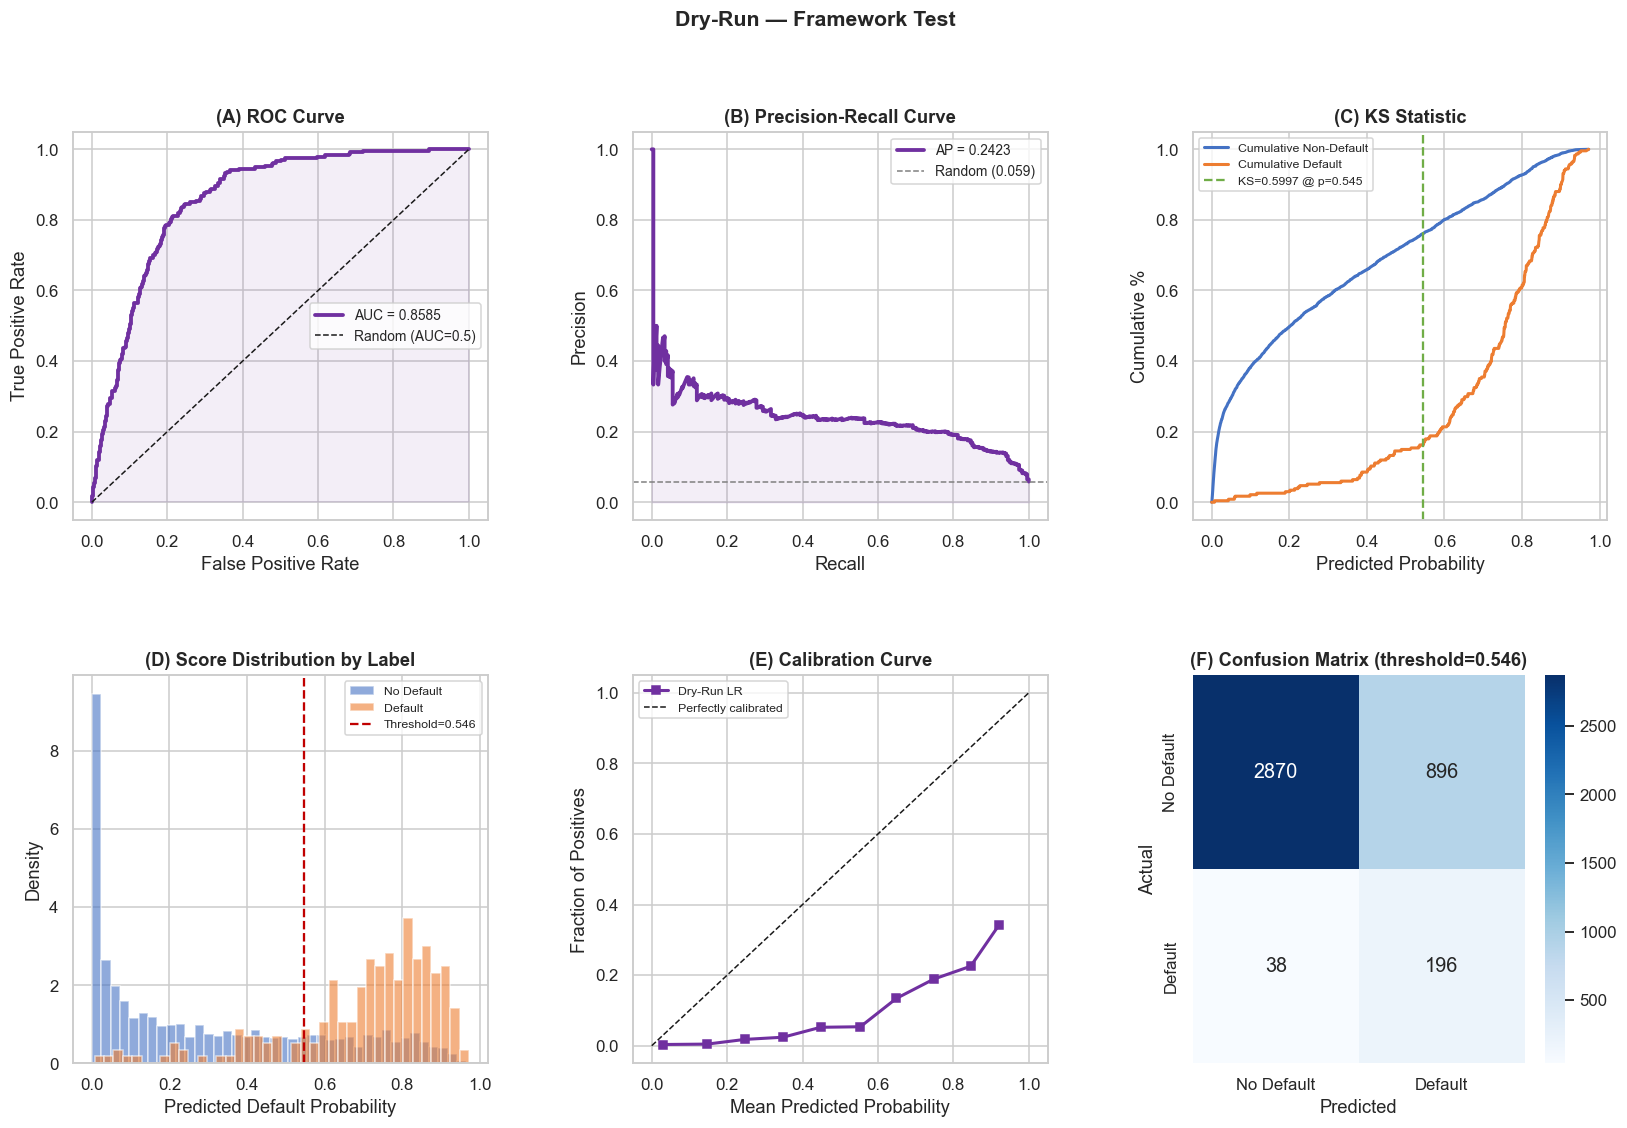


Classification Report (threshold = 0.546):
              precision    recall  f1-score   support

  No Default       0.99      0.76      0.86      3766
     Default       0.18      0.84      0.30       234

    accuracy                           0.77      4000
   macro avg       0.58      0.80      0.58      4000
weighted avg       0.94      0.77      0.83      4000


✓ All framework functions work correctly
✓ Ready to train real models in Parts 4.3 – 4.6


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Tiny LR just to test the framework
print("Dry-run: fitting a tiny Logistic Regression to test all functions...")
_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(class_weight="balanced", max_iter=200,
                                  C=0.01, solver="saga", random_state=42))
])
_lr.fit(X_train, y_train)

print()
print("evaluate_model() output:")
print("-" * 45)
_result = evaluate_model(
    name          = "Dry-Run LR",
    model         = _lr,
    X_tr          = X_train,
    y_tr          = y_train,
    X_te          = X_test,
    y_te          = y_test,
    sample_weight = sample_weights,
    cv            = CV,
    color         = PURPLE
)
print()
print("plot_model_dashboard() — rendering dashboard...")
plot_model_dashboard(_result, y_test, title="Dry-Run — Framework Test")

print()
print("✓ All framework functions work correctly")
print("✓ Ready to train real models in Parts 4.3 – 4.6")

## 10 — Save Framework for Downstream Notebooks

In [10]:
# Save the CV object so all notebooks use identical fold splits
joblib.dump(CV, "cv_strategy.pkl")
print("✓ cv_strategy.pkl saved")

# Save a metric reference JSON
metric_ref = {
    "primary_metric"    : "test_auc",
    "tiebreaker"        : "cv_mean",
    "all_metrics"       : ["test_auc","test_ap","gini","ks","cv_mean","cv_std","opt_thresh"],
    "cv_folds"          : 5,
    "cv_random_state"   : 42,
    "ks_good_threshold" : 0.3,
    "model_colors"      : {
        "Bureau Score"        : "#9E9E9E",
        "Logistic Regression" : "#FF9800",
        "Random Forest"       : "#70AD47",
        "Gradient Boosting"   : "#4472C4"
    }
}
with open("metric_reference.json","w") as f:
    json.dump(metric_ref, f, indent=2)
print("✓ metric_reference.json saved")
print()
print("Files available for Parts 4.3 – 4.10:")
for fname in ["X_train.npy","X_test.npy","y_train.npy","y_test.npy",
              "sample_weights.npy","preprocessing_meta.pkl",
              "cv_strategy.pkl","metric_reference.json"]:
    exists = "✓" if Path(fname).exists() else "✗  MISSING"
    print(f"  {exists}  {fname}")

✓ cv_strategy.pkl saved
✓ metric_reference.json saved

Files available for Parts 4.3 – 4.10:
  ✓  X_train.npy
  ✓  X_test.npy
  ✓  y_train.npy
  ✓  y_test.npy
  ✓  sample_weights.npy
  ✓  preprocessing_meta.pkl
  ✓  cv_strategy.pkl
  ✓  metric_reference.json


---
## Summary

### What was built in this notebook

| Component | Description |
|---|---|
| `CV` | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` — shared across all models |
| `ks_statistic()` | Returns KS value, optimal threshold, and full CDF DataFrame for plotting |
| `evaluate_model()` | Computes AUC, AP, Gini, KS, optimal threshold, CV AUC — in one call |
| `plot_model_dashboard()` | 6-panel dashboard: ROC, PR, KS, score distribution, calibration, confusion matrix |
| `plot_comparison()` | 4-panel comparison: ROC curves, PR curves, CV AUC bar, multi-metric bar |
| `results {}` | Shared dictionary — populated by 4.3–4.6, read by 4.7–4.10 |

### Files saved
```
cv_strategy.pkl        ← StratifiedKFold object (consistent splits across notebooks)
metric_reference.json  ← metric names, colours, thresholds
```

---
**Next → Part 4.3: Baseline — Bureau Score (`score_1`)**  
No training needed. We score the raw bureau score as a standalone predictor to set the benchmark every model must beat.